In [1]:
import numpy as np
import scipy.sparse as sp
import scipy.sparse.linalg as spla
import colormaps as cmpas

import scienceplots
import matplotlib.pyplot as plt
import seaborn as sns
import time

from nanonets import Simulation

plt.style.use(["science","bright","grid"])

In [110]:
import numpy as np
import scipy.sparse as sp
import scipy.sparse.linalg as spla
import time

class FDMSolver:
    """
    A Finite Difference Method (FDM) solver for 3D electrostatic capacitance.
    Optimized with an explicit grounded substrate to capture exact leakage.
    """
    def __init__(self, resolution=1.0):
        # Grid Resolution in nm
        self.res = resolution
        
        # Default Material Properties (Relative Permittivity)
        self.props = {
            'air': 1.0,  
            'filler': 2.6, 
            'sio2': 3.9
            # Removed 'si': 11.7 because it is now treated as a perfect metal ground
        }
        
        # Grid state
        self.epsilon = None
        self.conductor_mask = None
        self.nx = self.ny = self.nz = 0
        self.grid_coords = None # (X, Y, Z)
        
        # Solver state
        self.A_free = None
        self.is_free = None
        self.solver_ready = False
        
        # Results
        self.conductors = {} # Map ID -> Name
        
    def initialize_grid(self, width_nm, height_nm, z_start):
        """Creates the 3D voxel grid based on physical dimensions."""
        print(f"[Grid] Initializing {width_nm}x{width_nm}x{height_nm} nm volume...")

        self.nx = int(np.ceil(width_nm / self.res))
        self.ny = int(np.ceil(width_nm / self.res))
        self.nz = int(np.ceil(height_nm / self.res))
        
        total_nodes = self.nx * self.ny * self.nz
        print(f"[Grid] Nodes: {self.nx}x{self.ny}x{self.nz} ({total_nodes/1e6:.2f} Million)")
        
        # 1. Material Arrays
        self.epsilon = np.ones((self.nx, self.ny, self.nz), dtype=np.float32) * self.props['air']
        self.conductor_mask = np.zeros((self.nx, self.ny, self.nz), dtype=np.int16)
        
        # 2. Coordinate Mesh (for geometry definition)
        x = np.linspace(-width_nm/2, width_nm/2, self.nx)
        y = np.linspace(-width_nm/2, width_nm/2, self.ny)
        z = np.linspace(z_start, z_start + height_nm, self.nz)
        self.grid_coords = np.meshgrid(x, y, z, indexing='ij')

    def add_substrate_stack(self, sio2_thick, encapsulated=False):
        """Defines the SiO2 / Filler stack (Silicon is now the boundary ground)."""
        X, Y, Z = self.grid_coords
        
        # SiO2 Layer (from the absolute bottom up to 0)
        self.epsilon[(Z >= -sio2_thick) & (Z < 0)] = self.props['sio2']
        
        # Filler (Between spheres)
        if encapsulated:
            self.epsilon[Z >= 0] = self.props['filler']
        else:
            self.epsilon[(Z >= 0) & (Z <= 20.0)] = self.props['filler']

    def add_substrate_ground(self, sio2_thick):
        """
        Creates an explicit grounded electrode at the very bottom of the grid.
        This represents the heavily doped silicon back-gate.
        """
        print("[Geometry] Adding Explicit Substrate Ground Plane...")
        Z = self.grid_coords[2]
        e_id = 109 # Unique ID for the substrate
        
        # Select the absolute bottom layer of voxels
        mask = Z <= (-sio2_thick + 0.1 * self.res) 
        
        self.conductor_mask[mask] = e_id
        self.epsilon[mask] = 1000.0 # High permittivity for perfect conductor
        self.conductors[e_id] = "Substrate_Ground"
        
        return e_id

    def add_sphere_lattice(self, L, radius, gap):
        """Adds an LxL lattice of spheres."""
        pitch = 2 * radius + gap
        offset = (L - 1) * pitch / 2
        
        X, Y, Z = self.grid_coords
        sphere_ids = []
        count = 0
        
        print(f"[Geometry] Adding {L}x{L} Sphere Lattice...")
        for j in range(L): 
            for i in range(L):
                count += 1
                c_id = count 
                
                cx = i * pitch - offset
                cy = j * pitch - offset
                cz = radius
                
                dist_sq = (X - cx)**2 + (Y - cy)**2 + (Z - cz)**2
                mask = dist_sq <= radius**2
                
                self.conductor_mask[mask] = c_id
                self.epsilon[mask] = 1000.0 
                
                self.conductors[c_id] = f"Sphere_{c_id}_Pos({i},{j})"
                sphere_ids.append(c_id)
                
        return sphere_ids

    def add_surrounding_electrodes(self, lattice_span, margin, elec_dist, elec_size):
        """Adds 8 side electrodes."""
        print("[Geometry] Adding 8 Side Electrodes...")
        X, Y, Z = self.grid_coords
        
        width_nm = lattice_span + 2 * margin
        limit = width_nm / 2
        phys_edge = (lattice_span / 2) + 10.0 
        pos = phys_edge + elec_dist + elec_size/2
        
        electrode_defs = [
            ("Bottom",       0,   -pos), 
            ("Bottom-Left", -pos, -pos), 
            ("Bottom-Right", pos, -pos), 
            ("Left",        -pos,  0),   
            ("Right",        pos,  0),   
            ("Top-Left",    -pos,  pos), 
            ("Top-Right",    pos,  pos), 
            ("Top",          0,    pos), 
        ]
        
        generated_ids = []
        for idx, (name, cx, cy) in enumerate(electrode_defs):
            e_id = 101 + idx 
            
            half_s = elec_size / 2
            x_min, x_max = cx - half_s, cx + half_s
            y_min, y_max = cy - half_s, cy + half_s
            
            if cx < -1: x_min = -limit 
            if cx >  1: x_max =  limit 
            if cy < -1: y_min = -limit 
            if cy >  1: y_max =  limit 

            mask = (X >= x_min) & (X <= x_max) & \
                   (Y >= y_min) & (Y <= y_max) & \
                   (Z >= 0) & (Z <= 20.0) 
            
            self.conductor_mask[mask] = e_id
            self.epsilon[mask] = 1000.0
            
            self.conductors[e_id] = f"Elec_{idx+1}_{name}"
            generated_ids.append(e_id)
            
        return generated_ids

    def build_matrix(self):
        """Constructs the Sparse Laplacian Matrix."""
        print("[Solver] Building Matrix (this may take time)...")
        t0 = time.time()
        
        num_nodes = self.nx * self.ny * self.nz
        eps_flat = self.epsilon.flatten()
        cond_flat = self.conductor_mask.flatten()
        
        self.is_free = (cond_flat == 0)
        free_indices = np.arange(num_nodes)[self.is_free]
        
        entries_row, entries_col, entries_val = [], [], []
        diag_vals = np.zeros(num_nodes)
        neighbors = [(-1,0,0), (1,0,0), (0,-1,0), (0,1,0), (0,0,-1), (0,0,1)]
        
        ix, iy, iz = np.unravel_index(free_indices, (self.nx, self.ny, self.nz))
        
        for dx, dy, dz in neighbors:
            n_ix, n_iy, n_iz = ix + dx, iy + dy, iz + dz
            valid = (n_ix >= 0) & (n_ix < self.nx) & \
                    (n_iy >= 0) & (n_iy < self.ny) & \
                    (n_iz >= 0) & (n_iz < self.nz)
            
            if not np.any(valid): continue

            valid_src = free_indices[valid]
            valid_tgt = np.ravel_multi_index(
                (n_ix[valid], n_iy[valid], n_iz[valid]), 
                (self.nx, self.ny, self.nz)
            )
            
            eps_here = eps_flat[valid_src]
            eps_there = eps_flat[valid_tgt]
            cond = 2.0 * (eps_here * eps_there) / (eps_here + eps_there)
            
            entries_row.extend(valid_src)
            entries_col.extend(valid_tgt)
            entries_val.extend(-cond)
            np.add.at(diag_vals, valid_src, cond)
            
        entries_row.extend(free_indices)
        entries_col.extend(free_indices)
        entries_val.extend(diag_vals[free_indices])
        
        self.A = sp.coo_matrix((entries_val, (entries_row, entries_col)), shape=(num_nodes, num_nodes))
        self.A = self.A.tocsr()
        self.A_free = self.A[self.is_free][:, self.is_free]
        
        print(f"[Solver] Matrix built in {time.time()-t0:.1f}s.")
        self.solver_ready = True

    def solve(self, active_ids, passive_ids):
        """Solves for the capacitance matrix."""
        if not self.solver_ready:
            raise RuntimeError("Matrix not built.")
            
        n_active = len(active_ids)
        n_passive = len(passive_ids)
        
        C_internal = np.zeros((n_active, n_active)) 
        C_coupling = np.zeros((n_passive, n_active)) 
        scale = 8.854e-12 * (self.res * 1e-9) 
        
        print(f"[Solver] Starting Iterative Solution for {n_active} spheres...")
        for idx, s_id in enumerate(active_ids):
            print(f"  -> Solving Sphere ID {s_id}...")
            b_vector = self._compute_rhs(s_id)
            phi_free, info = spla.cg(self.A_free, b_vector, rtol=1e-5, atol=1e-8, maxiter=5000)
            if info > 0: print("WARNING: Solver did not converge.")
            
            phi_full = np.zeros(self.nx * self.ny * self.nz)
            phi_full[self.is_free] = phi_free
            mask_active = (self.conductor_mask.flatten() == s_id)
            phi_full[mask_active] = 1.0
            
            for row_idx, target_id in enumerate(active_ids):
                q = self._get_flux(phi_full, target_id)
                C_internal[row_idx, idx] = q * scale
            
            for row_idx, target_id in enumerate(passive_ids):
                q = self._get_flux(phi_full, target_id)
                C_coupling[row_idx, idx] = q * scale
                
        return C_internal, C_coupling

    def _compute_rhs(self, active_id):
        num_nodes = self.nx * self.ny * self.nz
        rhs = np.zeros(num_nodes)
        cond_flat = self.conductor_mask.flatten()
        eps_flat = self.epsilon.flatten()
        
        active_nodes = np.where(cond_flat == active_id)[0]
        neighbors = [(-1,0,0), (1,0,0), (0,-1,0), (0,1,0), (0,0,-1), (0,0,1)]
        ix, iy, iz = np.unravel_index(active_nodes, (self.nx, self.ny, self.nz))
        
        for dx, dy, dz in neighbors:
            n_ix, n_iy, n_iz = ix + dx, iy + dy, iz + dz
            valid = (n_ix >= 0) & (n_ix < self.nx) & \
                    (n_iy >= 0) & (n_iy < self.ny) & \
                    (n_iz >= 0) & (n_iz < self.nz)
            
            if not np.any(valid): continue
            
            src = active_nodes[valid]
            tgt = np.ravel_multi_index((n_ix[valid], n_iy[valid], n_iz[valid]), (self.nx, self.ny, self.nz))
            
            is_tgt_free = (cond_flat[tgt] == 0)
            valid_src = src[is_tgt_free]
            valid_tgt = tgt[is_tgt_free]
            
            eps_in = eps_flat[valid_src]
            eps_out = eps_flat[valid_tgt]
            cond = 2.0 * (eps_in * eps_out) / (eps_in + eps_out)
            
            np.add.at(rhs, valid_tgt, cond)
            
        return rhs[self.is_free]

    def _get_flux(self, phi, c_id):
        cond_flat = self.conductor_mask.flatten()
        c_nodes = np.where(cond_flat == c_id)[0]
        eps_flat = self.epsilon.flatten()
        
        if len(c_nodes) == 0: return 0.0
        
        flux_sum = 0.0
        neighbors = [(-1,0,0), (1,0,0), (0,-1,0), (0,1,0), (0,0,-1), (0,0,1)]
        ix, iy, iz = np.unravel_index(c_nodes, (self.nx, self.ny, self.nz))
        
        for dx, dy, dz in neighbors:
            n_ix, n_iy, n_iz = ix + dx, iy + dy, iz + dz
            valid = (n_ix >= 0) & (n_ix < self.nx) & \
                    (n_iy >= 0) & (n_iy < self.ny) & \
                    (n_iz >= 0) & (n_iz < self.nz)
            
            if not np.any(valid): continue
            
            src = c_nodes[valid]
            tgt = np.ravel_multi_index((n_ix[valid], n_iy[valid], n_iz[valid]), (self.nx, self.ny, self.nz))
            
            is_tgt_free = (cond_flat[tgt] == 0)
            valid_src = src[is_tgt_free]
            valid_tgt = tgt[is_tgt_free]
            
            v_nbr = phi[valid_tgt]
            v_self = phi[valid_src] 
            
            eps_in = eps_flat[valid_src]
            eps_out = eps_flat[valid_tgt]
            cond = 2.0 * (eps_in * eps_out) / (eps_in + eps_out)
            
            flux = cond * (v_self - v_nbr)
            flux_sum += np.sum(flux)
            
        return flux_sum

# ==========================================
# USAGE EXAMPLE
# ==========================================
if __name__ == "__main__":
    
    # 1. Configuration
    L = 7
    radius_nm = 10.0
    gap_nm = 1.0
    sio2_nm = 35.0
    
    # Calculate Dimensions
    pitch = 2 * radius_nm + gap_nm
    lattice_span = (L - 1) * pitch 
    
    elec_size = 20.0
    elec_dist = 1.0
    margin = elec_dist + elec_size + 10.0
    
    width_total = lattice_span + 2 * (radius_nm + margin)
    
    # --- UPDATED HEIGHT LOGIC ---
    # The grid now cuts off exactly at the bottom of the SiO2 layer!
    height_total = sio2_nm + 50.0 
    z_start = -sio2_nm 
    
    # 2. Instantiate Solver
    solver = FDMSolver(resolution=1.0) 
    
    # 3. Setup Geometry
    solver.initialize_grid(width_total, height_total, z_start)
    solver.add_substrate_stack(sio2_thick=sio2_nm, encapsulated=False)
    
    # Add Conductors
    sphere_ids = solver.add_sphere_lattice(L=L, radius=radius_nm, gap=gap_nm)
    electrode_ids = solver.add_surrounding_electrodes(lattice_span, margin, elec_dist, elec_size)
    
    # --- ADD THE SUBSTRATE AS A PASSIVE ELECTRODE ---
    sub_id = solver.add_substrate_ground(sio2_nm)
    electrode_ids.append(sub_id) # Electrode array is now 9xN
    
    # 4. Build & Solve
    solver.build_matrix()
    C_sph, C_elec = solver.solve(active_ids=sphere_ids, passive_ids=electrode_ids)
    
    # Output
    print("\n--- 9xN Electrode & Substrate Coupling Matrix (aF) ---")
    labels = ["1:Bot", "2:BL", "3:BR", "4:L", "5:R", "6:TL", "7:TR", "8:Top", "9:Substrate"]
    
    print(f"{'IDX':<8} {'Label':<12} | Couplings to Spheres 1..N")
    print("-" * 85)
    for i, row in enumerate(C_elec):
        data_str = "  ".join([f"{val*1e18:6.2f}" for val in row])
        print(f"{i+1:<8} {labels[i]:<12} | {data_str}")

    np.savetxt(fname=f'data_ref/c_mat_L={L}.csv', X=C_sph*1e18)
    np.savetxt(fname=f'data_ref/c_ele_L={L}.csv', X=np.abs(C_elec)*1e18)

[Grid] Initializing 208.0x208.0x85.0 nm volume...
[Grid] Nodes: 208x208x85 (3.68 Million)
[Geometry] Adding 7x7 Sphere Lattice...
[Geometry] Adding 8 Side Electrodes...
[Geometry] Adding Explicit Substrate Ground Plane...
[Solver] Building Matrix (this may take time)...
[Solver] Matrix built in 12.5s.
[Solver] Starting Iterative Solution for 49 spheres...
  -> Solving Sphere ID 1...
  -> Solving Sphere ID 2...
  -> Solving Sphere ID 3...
  -> Solving Sphere ID 4...
  -> Solving Sphere ID 5...
  -> Solving Sphere ID 6...
  -> Solving Sphere ID 7...
  -> Solving Sphere ID 8...
  -> Solving Sphere ID 9...
  -> Solving Sphere ID 10...
  -> Solving Sphere ID 11...
  -> Solving Sphere ID 12...
  -> Solving Sphere ID 13...
  -> Solving Sphere ID 14...
  -> Solving Sphere ID 15...
  -> Solving Sphere ID 16...
  -> Solving Sphere ID 17...
  -> Solving Sphere ID 18...
  -> Solving Sphere ID 19...
  -> Solving Sphere ID 20...
  -> Solving Sphere ID 21...
  -> Solving Sphere ID 22...
  -> Solving 

In [2]:
L       = 7
c_mat   = np.loadtxt(fname=f'data_ref/c_mat_L={L}.csv')
c_ele   = np.loadtxt(fname=f'data_ref/c_ele_L={L}.csv')

In [3]:
color=cmpas.lipari(0.1)

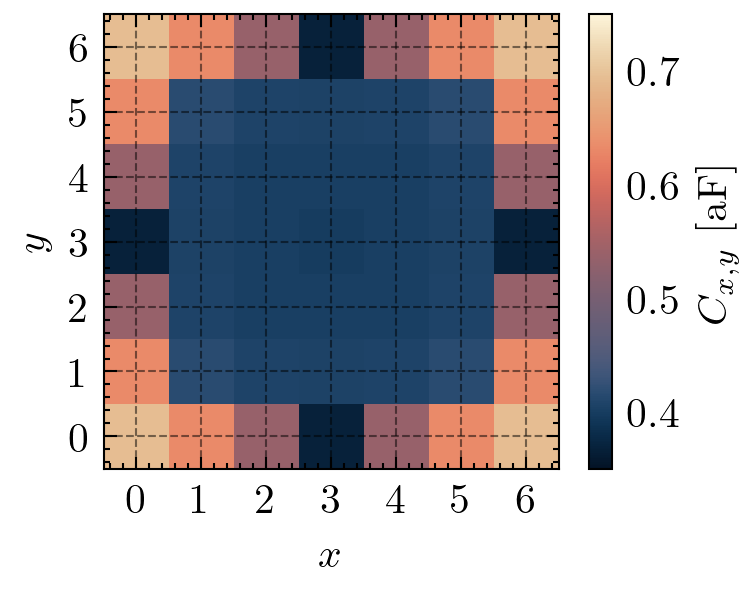

In [5]:
fig     = plt.figure(dpi=300)
ax      = fig.add_subplot()
w, h    = fig.get_size_inches()
scale   = 0.75
_       = fig.set_size_inches(w * scale, h * scale)
im      = ax.imshow(c_ele[-1,:].reshape(L,L), cmap=cmpas.lipari, vmin=0.35, vmax=0.75, origin='lower')
_       = ax.set_xticks(np.arange(L))
_       = ax.set_yticks(np.arange(L))
cb      = fig.colorbar(im, label='$C_{x,y}~[\mathrm{aF}]$')
_       = ax.set_xlabel('$x$')
_       = ax.set_ylabel('$y$')

fig.savefig(f"plots/png/NP_to_substrate_capacitance_FMD.png", transparent=False)
fig.savefig(f"plots/pdf/NP_to_substrate_capacitance_FMD.pdf", transparent=False)
fig.savefig(f"plots/svg/NP_to_substrate_capacitance_FMD.svg", transparent=True)

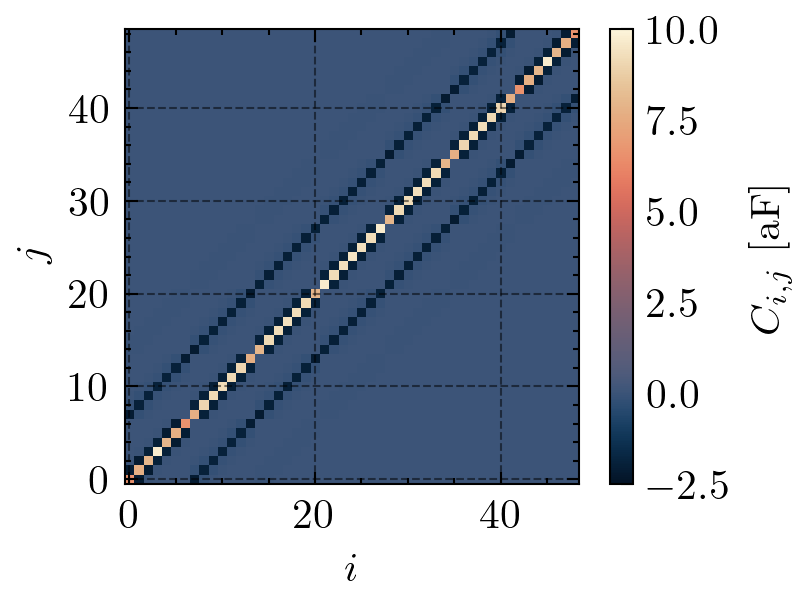

In [6]:
fig     = plt.figure(dpi=300)
ax      = fig.add_subplot()
w, h    = fig.get_size_inches()
scale   = 0.75
_       = fig.set_size_inches(w * scale, h * scale)
im      = ax.imshow(c_mat, cmap=cmpas.lipari, vmin=-2.5, vmax=10.0, origin='lower')
cb      = fig.colorbar(im, label='$C_{i,j}~[\mathrm{aF}]$')
_       = ax.set_xlabel('$i$')
_       = ax.set_ylabel('$j$')

fig.savefig(f"plots/png/capacitance_matrix_FMD.png", transparent=False)
fig.savefig(f"plots/pdf/capacitance_matrix_FMD.pdf", transparent=False)
fig.savefig(f"plots/svg/capacitance_matrix_FMD.svg", transparent=True)

In [17]:
Ce_vals

array([2.94963585, 1.20825185, 1.20825185, 2.94963585, 2.94963585,
       1.20825185, 1.20825185, 2.94963585])

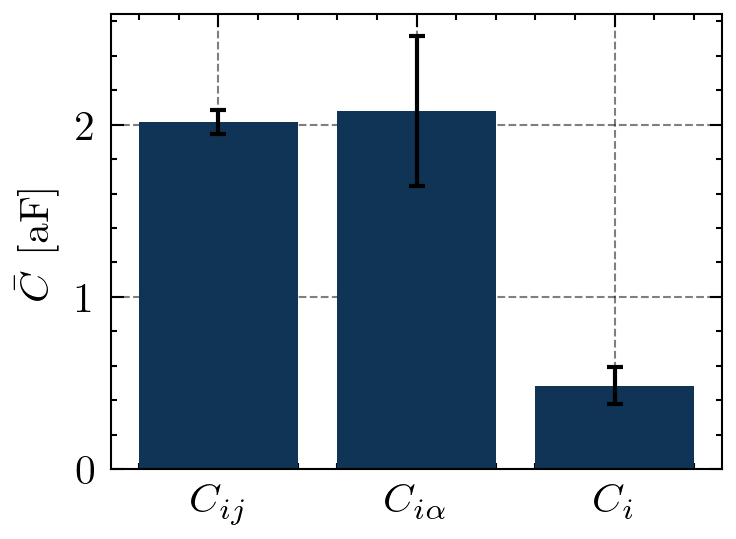

In [19]:
Cm_vals = np.abs(c_mat[np.where(c_mat < -1)])
Cg_vals = c_ele[-1,:]
Ce_vals = c_ele[:-1,:][np.where(c_ele[:-1,:]>1.0)]

fig     = plt.figure(dpi=300)
ax      = fig.add_subplot()
w, h    = fig.get_size_inches()
scale   = 0.75
_       = fig.set_size_inches(w * scale, h * scale)
im      = ax.bar(['$C_{ij}$','$C_{i\\alpha}$','$C_{i}$'], [np.mean(Cm_vals), np.mean(Ce_vals), np.mean(Cg_vals)], capsize=2, color=cmpas.lipari(0.1), 
            #      yerr=[[np.mean(Cm_vals)-np.min(Cm_vals), np.mean(Ce_vals)-np.min(Ce_vals), np.mean(Cg_vals)-np.min(Cg_vals)],
            #            [np.max(Cm_vals)-np.mean(Cm_vals), np.max(Ce_vals)-np.mean(Ce_vals), np.max(Cg_vals)-np.mean(Cg_vals)]])
                yerr=[np.std(Cm_vals), np.std(Ce_vals)/2, np.std(Cg_vals)])
_       = ax.set_ylabel('$\\bar{C}~[\mathrm{aF}]$')

fig.savefig(f"plots/png/capacitance_comparsion.png", transparent=False)
fig.savefig(f"plots/pdf/capacitance_comparsion.pdf", transparent=False)
fig.savefig(f"plots/svg/capacitance_comparsion.svg", transparent=True)